In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(12,6)

# Initial data Exploration for NASA C-MAPSS Turbofan Engine Dataset

In [11]:
columns = ['unit_number','time_cycles','op_setting_1','op_setting_2','op_setting_3'] + [f'sensor_{i}' for i in range(1,22)]

In [12]:
train_df = pd.read_csv('train_FD001.txt',sep=r'\s+',header = None,names=columns)

In [13]:
train_df

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [14]:
train_df.shape

(20631, 26)

In [15]:
test_df = pd.read_csv('test_FD001.txt',sep=r'\s+',header = None,names=columns)

In [16]:
rul_df = pd.read_csv('RUL_FD001.txt',sep=r'\s+',header = None,names=columns)

In [19]:
test_df.shape

(13096, 26)

In [20]:
rul_df.shape

(100, 26)

In [21]:
rul_df.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Understanding Data Structure

#### How many unique engines?


In [23]:
print(f'Number of engines: {train_df['unit_number'].nunique()}')

Number of engines: 100


#### How many cycles does each engine run?

In [26]:
cycles_per_engine = train_df.groupby('unit_number')['time_cycles'].max()
print(f'\nCycles per engine: {cycles_per_engine}')


Cycles per engine: unit_number
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: time_cycles, Length: 100, dtype: int64


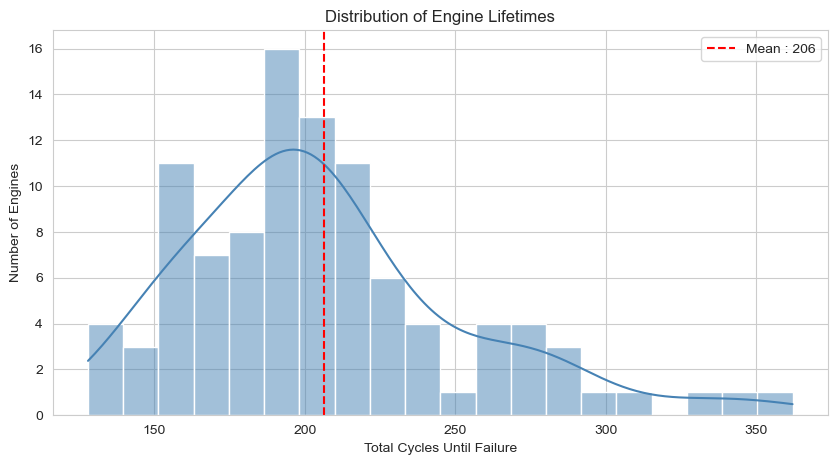

In [32]:
plt.figure(figsize=(10,5))
sns.histplot(cycles_per_engine,bins = 20,kde = True,color = 'steelblue')
plt.title('Distribution of Engine Lifetimes')
plt.xlabel('Total Cycles Until Failure')
plt.ylabel('Number of Engines')
plt.axvline(cycles_per_engine.mean(),color = 'red',linestyle='--',label=f'Mean : {cycles_per_engine.mean():.0f}')
plt.legend()
plt.show()


In [33]:
print("Operating settings statistics")
train_df[['op_setting_1','op_setting_2','op_setting_3']].describe()

Operating settings statistics


,op_setting_1,op_setting_2,op_setting_3
count,20631.000000,20631.000000,20631.0
mean,-0.000009,0.000002,100.0
std,0.002187,0.000293,0.0
min,-0.008700,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,0.000000,0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008700,0.000600,100.0


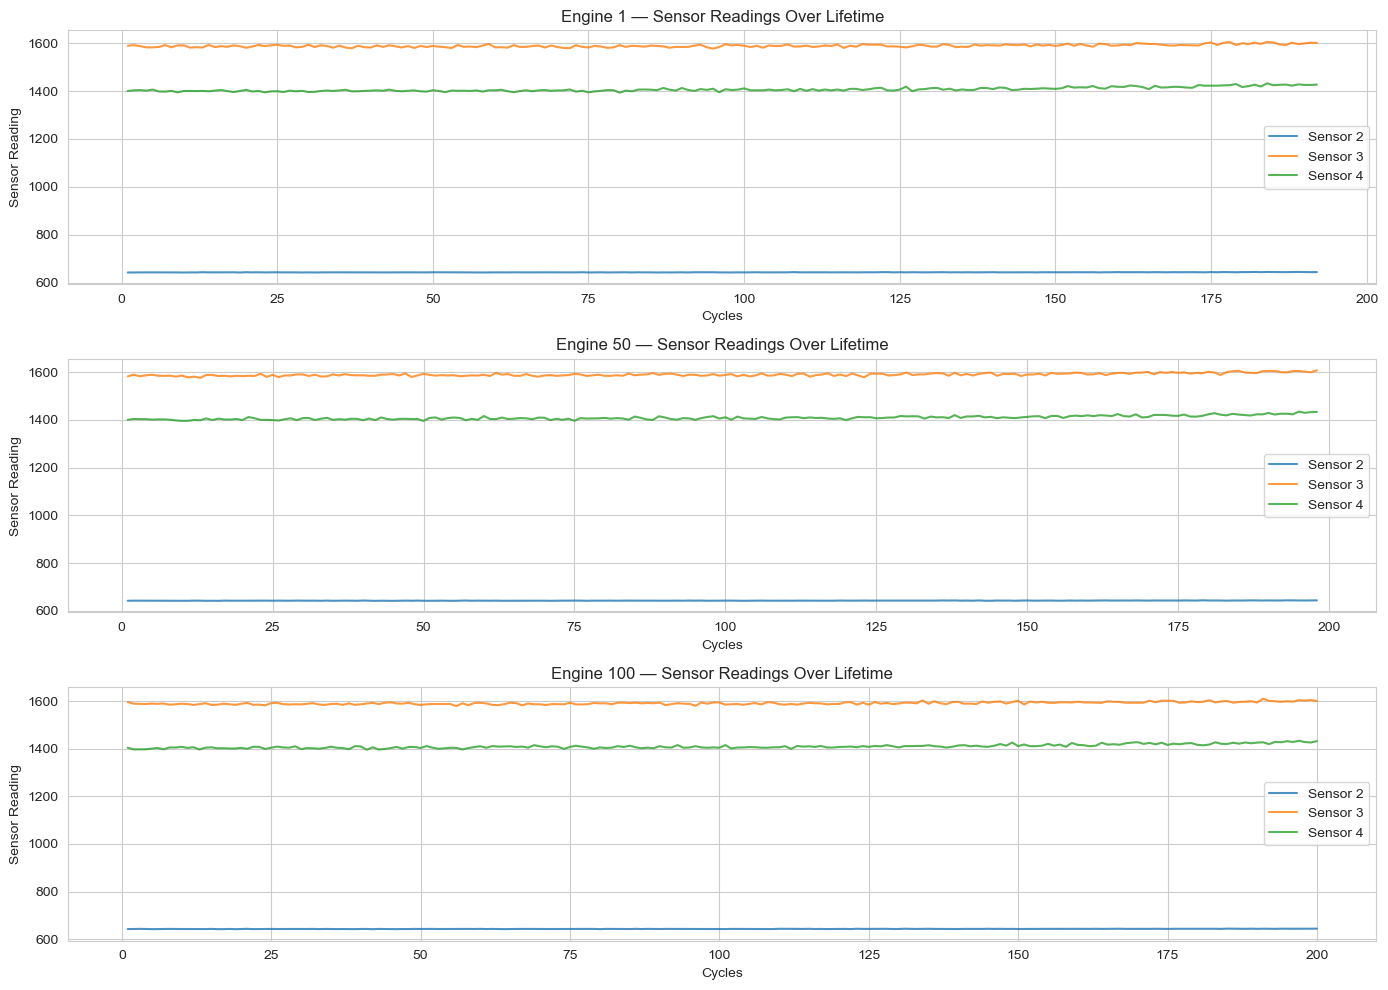

<module 'matplotlib.pyplot' from 'C:\\Users\\Aanchal Shah\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [36]:
# Pick 3 random engines
sample_engines = [1, 50, 100]  # use specific ones for reproducibility

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, engine_id in zip(axes, sample_engines):
    engine_data = train_df[train_df['unit_number'] == engine_id]
    ax.plot(engine_data['time_cycles'], engine_data['sensor_2'], 
            label='Sensor 2', alpha=0.8)
    ax.plot(engine_data['time_cycles'], engine_data['sensor_3'], 
            label='Sensor 3', alpha=0.8)
    ax.plot(engine_data['time_cycles'], engine_data['sensor_4'], 
            label='Sensor 4', alpha=0.8)
    ax.set_title(f'Engine {engine_id} — Sensor Readings Over Lifetime')
    ax.set_xlabel('Cycles')
    ax.set_ylabel('Sensor Reading')
    ax.legend()

plt.tight_layout()
plt.savefig('sensor_trends_sample.png', dpi=150, bbox_inches='tight')
plt.show()
plt

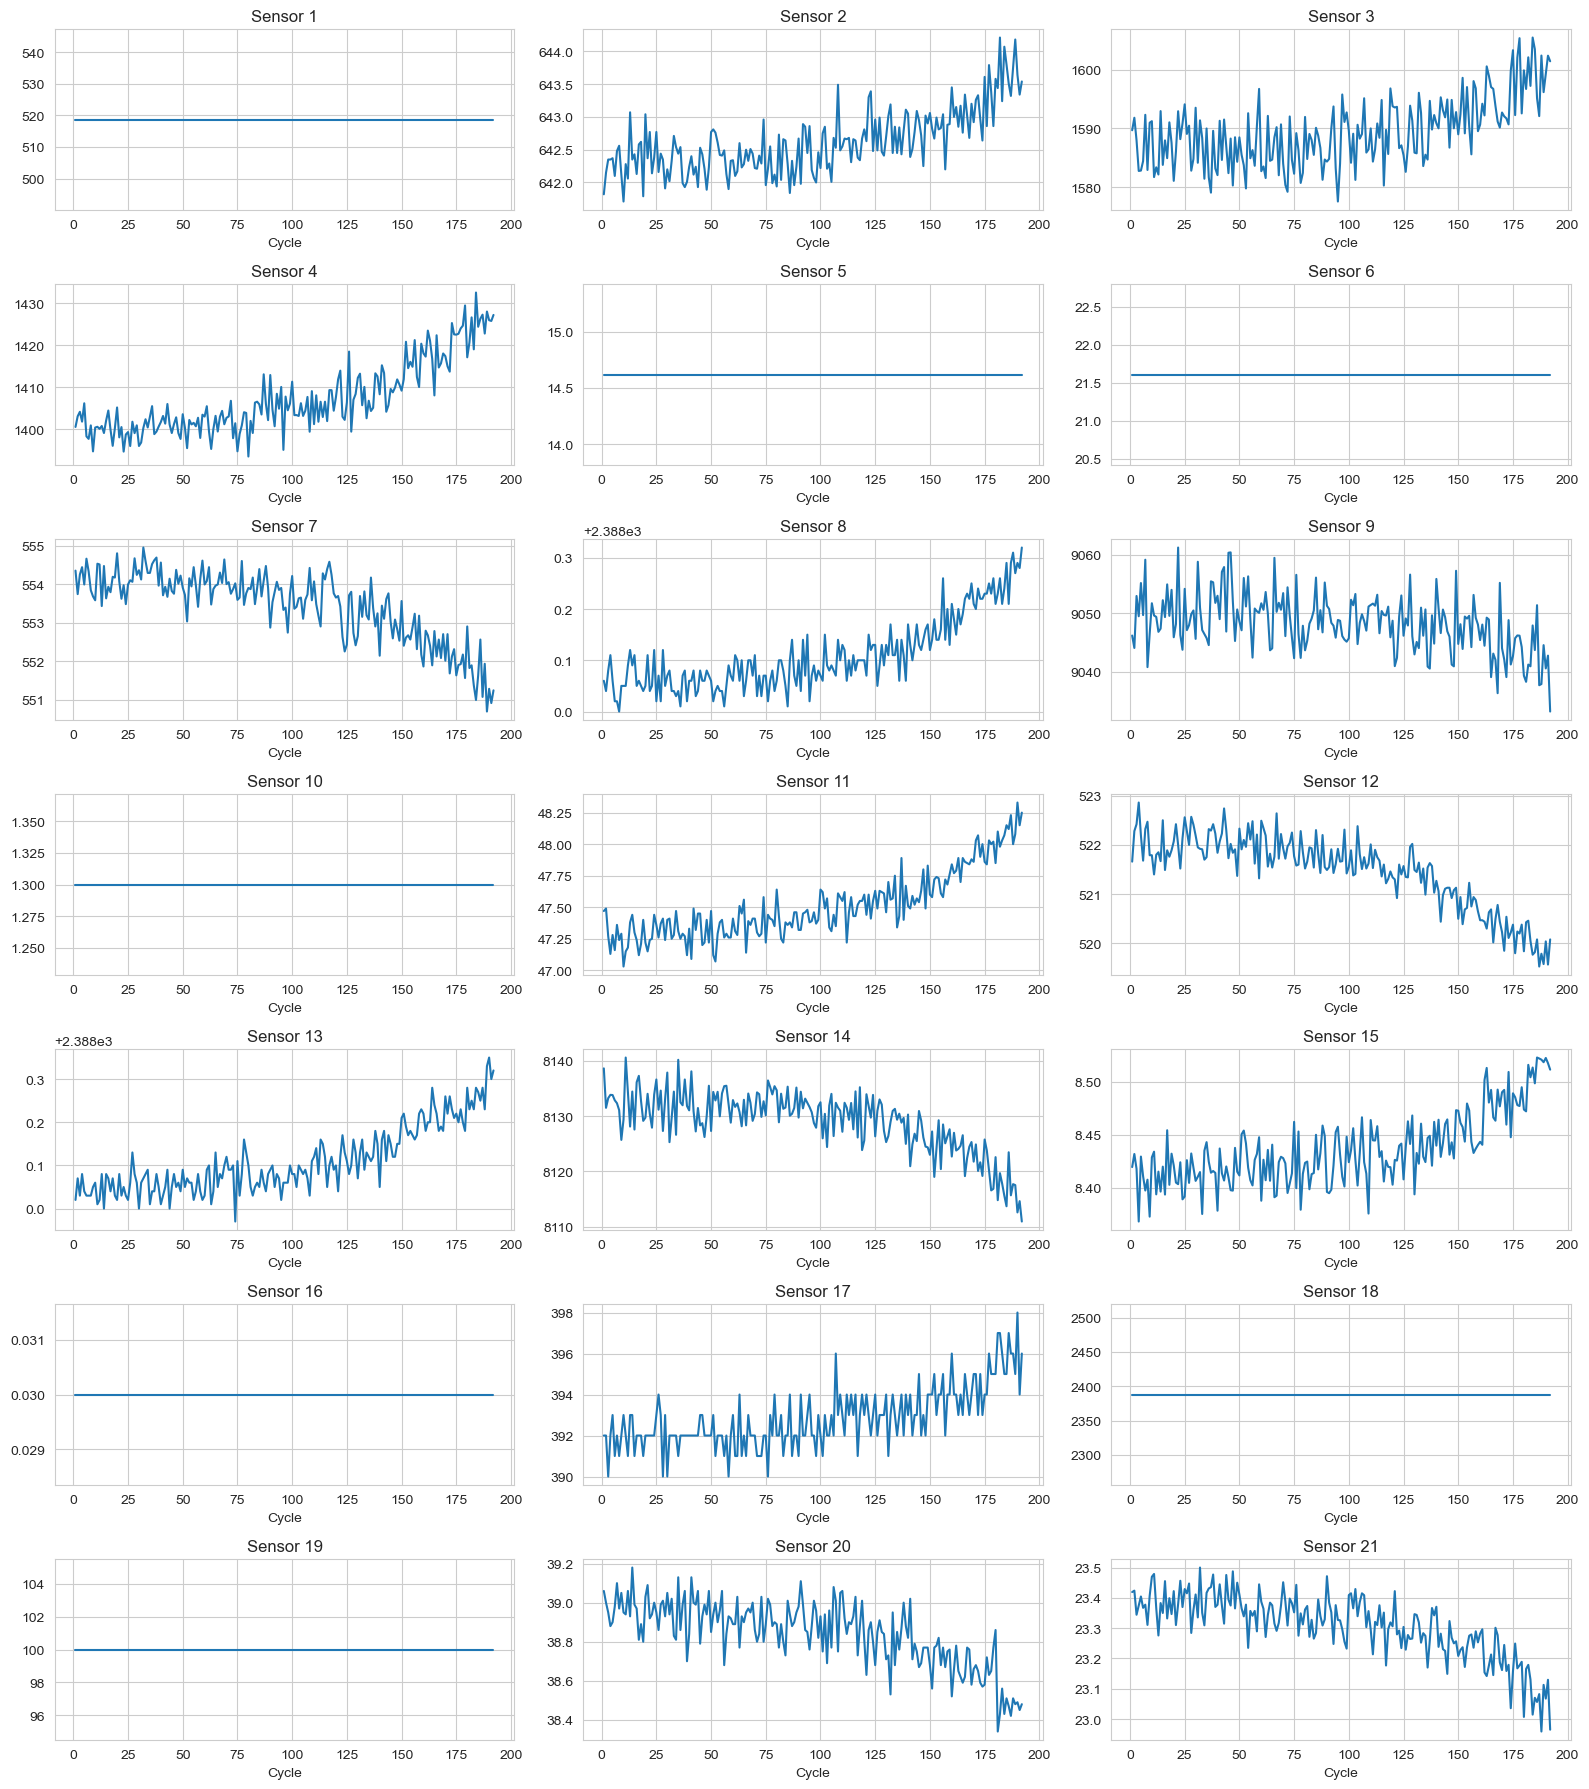

<module 'matplotlib.pyplot' from 'C:\\Users\\Aanchal Shah\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [41]:
engine_1 = train_df[train_df['unit_number']==1]
fig,axes = plt.subplots(7,3,figsize=(16,18))
axes = axes.flatten()

for i in range(1,22):
    axes[i-1].plot(engine_1['time_cycles'],engine_1[f'sensor_{i}'])
    axes[i-1].set_title(f'Sensor {i}')
    axes[i-1].set_xlabel('Cycle')

plt.tight_layout()
plt.savefig('all_sensors_engine1.png', dpi=150, bbox_inches='tight')
plt.show()
plt

#### Sensors 1,5,10,16,18,19 have zero variance nearly, these are constants we will drop them later

## Correlation Heatmap

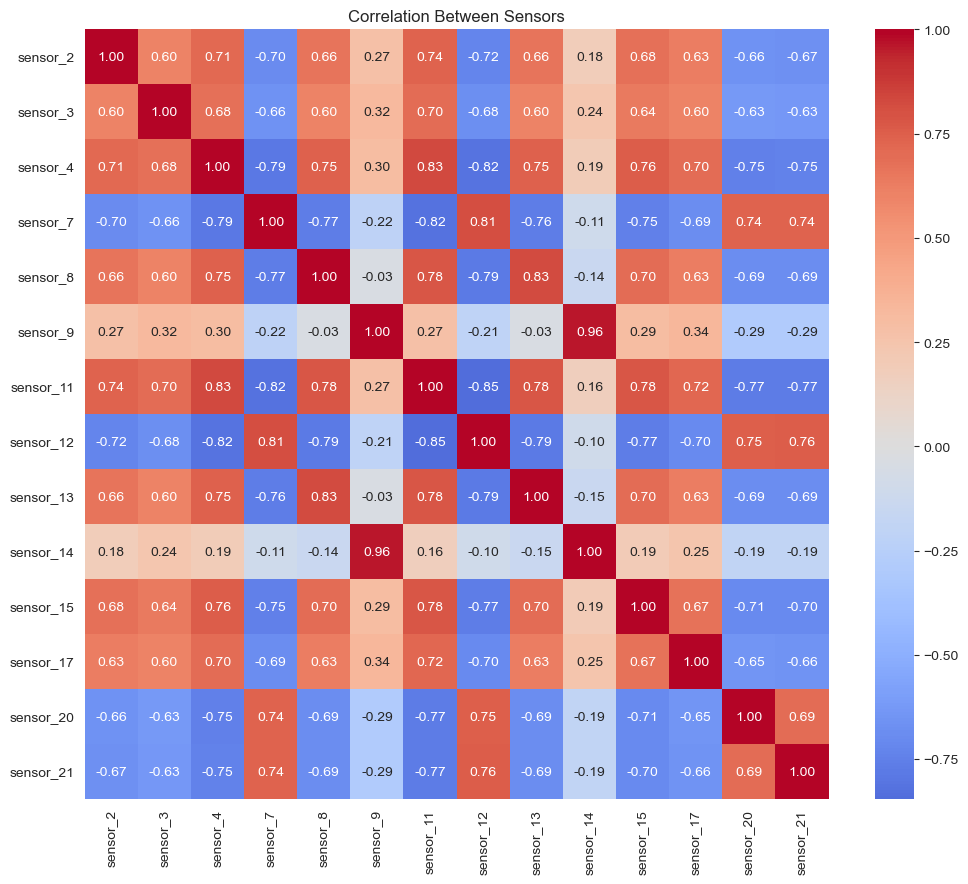

In [39]:
# Correlation between sensors (drop the constant ones first for clarity)
useful_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 
                   'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 
                   'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 
                   'sensor_20', 'sensor_21']

plt.figure(figsize=(12, 10))
sns.heatmap(train_df[useful_sensors].corr(), annot=True, 
            cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Sensors')
plt.savefig('sensor_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# Means sensor 14 and sensor 9 measures similar physical phenomena

In [42]:
# For each engine, find its max cycle (= the cycle at which it failed)
max_cycles = train_df.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']

# Merge back into the main df
train_df = train_df.merge(max_cycles, on='unit_number', how='left')

# RUL = remaining cycles before failure
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']

# Drop the helper column
train_df = train_df.drop('max_cycle', axis=1)

# Check it worked
print(train_df[['unit_number', 'time_cycles', 'RUL']].head())
print("\nEngine 1's last 5 rows (RUL should go down to 0):")
print(train_df[train_df['unit_number'] == 1].tail()[['unit_number', 'time_cycles', 'RUL']])

   unit_number  time_cycles  RUL
0            1            1  191
1            1            2  190
2            1            3  189
3            1            4  188
4            1            5  187

Engine 1's last 5 rows (RUL should go down to 0):
     unit_number  time_cycles  RUL
187            1          188    4
188            1          189    3
189            1          190    2
190            1          191    1
191            1          192    0


In [43]:
print("Columns now:",train_df.columns.tolist())
print(train_df['RUL'].describe())

Columns now: ['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'RUL']
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64
